# Kaggle Comp - Playground S5E9 - Predicting BPM

In [ ]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

pl.Config.set_tbl_cols(-1)
sns.set(style="whitegrid", palette="muted", font_scale=1.1)

df = pl.read_csv("train.csv")  
print("Shape of dataset:", df.shape)

df.head()

Shape of dataset: (524164, 11)


id,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,0.60361,-7.636942,0.0235,0.000005,0.000001,0.051385,0.409866,290715.645,0.826267,147.5302
1,0.639451,-16.267598,0.07152,0.444929,0.349414,0.170522,0.65101,164519.5174,0.1454,136.15963
2,0.514538,-15.953575,0.110715,0.173699,0.453814,0.029576,0.423865,174495.5667,0.624667,55.31989
3,0.734463,-1.357,0.052965,0.001651,0.159717,0.086366,0.278745,225567.4651,0.487467,147.91212
4,0.532968,-13.056437,0.0235,0.068687,0.000001,0.331345,0.477769,213960.6789,0.947333,89.58511


## 0. Initial Data Info & Analysis

In [2]:
# Check for missing values by feature
missing_values = df.null_count()
print("Missing values by feature:\n", missing_values)

# Check for duplicate rows
num_duplicates = df.is_duplicated().sum()
print(f"\nNumber of duplicate rows: {num_duplicates}")

Missing values by feature:
 shape: (1, 11)
┌─────┬─────────┬─────────┬─────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┐
│ id  ┆ RhythmS ┆ AudioLo ┆ VocalCo ┆ Acoust ┆ Instru ┆ LivePe ┆ MoodSc ┆ TrackD ┆ Energy ┆ BeatsP │
│ --- ┆ core    ┆ udness  ┆ ntent   ┆ icQual ┆ mental ┆ rforma ┆ ore    ┆ uratio ┆ ---    ┆ erMinu │
│ u32 ┆ ---     ┆ ---     ┆ ---     ┆ ity    ┆ Score  ┆ nceLik ┆ ---    ┆ nMs    ┆ u32    ┆ te     │
│     ┆ u32     ┆ u32     ┆ u32     ┆ ---    ┆ ---    ┆ elihoo ┆ u32    ┆ ---    ┆        ┆ ---    │
│     ┆         ┆         ┆         ┆ u32    ┆ u32    ┆ d      ┆        ┆ u32    ┆        ┆ u32    │
│     ┆         ┆         ┆         ┆        ┆        ┆ ---    ┆        ┆        ┆        ┆        │
│     ┆         ┆         ┆         ┆        ┆        ┆ u32    ┆        ┆        ┆        ┆        │
╞═════╪═════════╪═════════╪═════════╪════════╪════════╪════════╪════════╪════════╪════════╪════════╡
│ 0   ┆ 0       ┆ 0       ┆ 0       ┆ 0      ┆ 0

In [3]:
# Display descriptive statistics for the dataframe
df.describe()

statistic,id,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",524164.0,524164.0,524164.0,524164.0,524164.0,524164.0,524164.0,524164.0,524164.0,524164.0,524164.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",262081.5,0.632843,-8.379014,0.074443,0.262913,0.11769,0.178398,0.555843,241903.692949,0.500923,119.034899
"""std""",151313.257587,0.156899,4.616221,0.049939,0.22312,0.131845,0.118186,0.22548,59326.601501,0.289952,26.468077
"""min""",0.0,0.0769,-27.509725,0.0235,0.000005,0.000001,0.0243,0.0256,63973.0,0.0000667,46.718
"""25%""",131041.0,0.51585,-11.551933,0.0235,0.069413,0.000001,0.077638,0.403921,207099.8793,0.254933,101.07041
"""50%""",262082.0,0.634686,-8.252498,0.066425,0.242502,0.074248,0.166327,0.564817,243684.0869,0.5118,118.74766
"""75%""",393122.0,0.739179,-4.912299,0.107342,0.396956,0.204065,0.268946,0.716633,281851.6088,0.746,136.68659
"""max""",524163.0,0.975,-1.357,0.256401,0.995,0.869258,0.599924,0.978,464723.2281,1.0,206.037


## 1. EDA

Target variable statistics:
shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 524164.0   │
│ null_count ┆ 0.0        │
│ mean       ┆ 119.034899 │
│ std        ┆ 26.468077  │
│ min        ┆ 46.718     │
│ 25%        ┆ 101.07041  │
│ 50%        ┆ 118.74766  │
│ 75%        ┆ 136.68659  │
│ max        ┆ 206.037    │
└────────────┴────────────┘


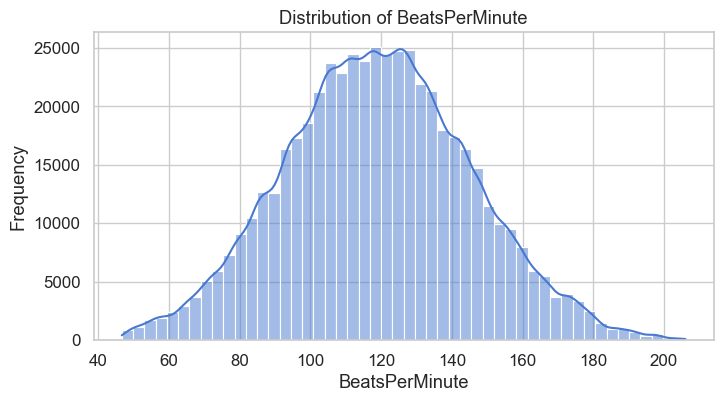

In [4]:
# Target Variable Analysis: 'BeatsPerMinute'
target_col = "BeatsPerMinute"

# Basic statistics
print("Target variable statistics:")
print(df[target_col].describe())

# Distribution plot
plt.figure(figsize=(8, 4))
sns.histplot(df[target_col].to_numpy(), bins=50, kde=True)
plt.title("Distribution of BeatsPerMinute")
plt.xlabel("BeatsPerMinute")
plt.ylabel("Frequency")
plt.show()

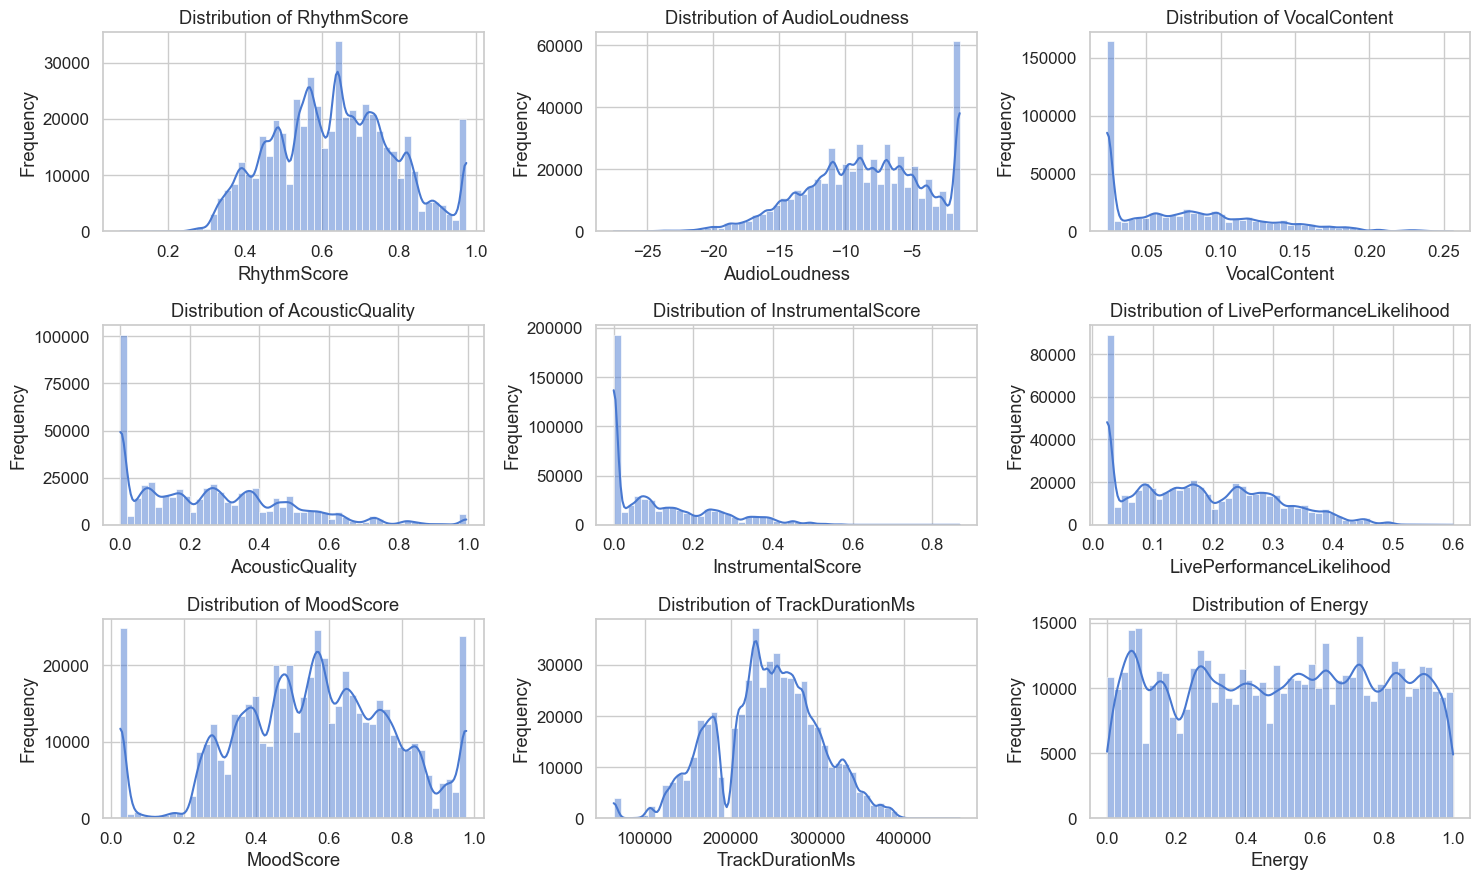

In [5]:
# Plot distributions for all features except the target and id
feature_cols = [col for col in df.columns if col not in ["id", target_col]]

n_cols = 3
n_rows = int(np.ceil(len(feature_cols) / n_cols))
plt.figure(figsize=(n_cols * 5, n_rows * 3))

for i, col in enumerate(feature_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[col].to_numpy(), bins=50, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

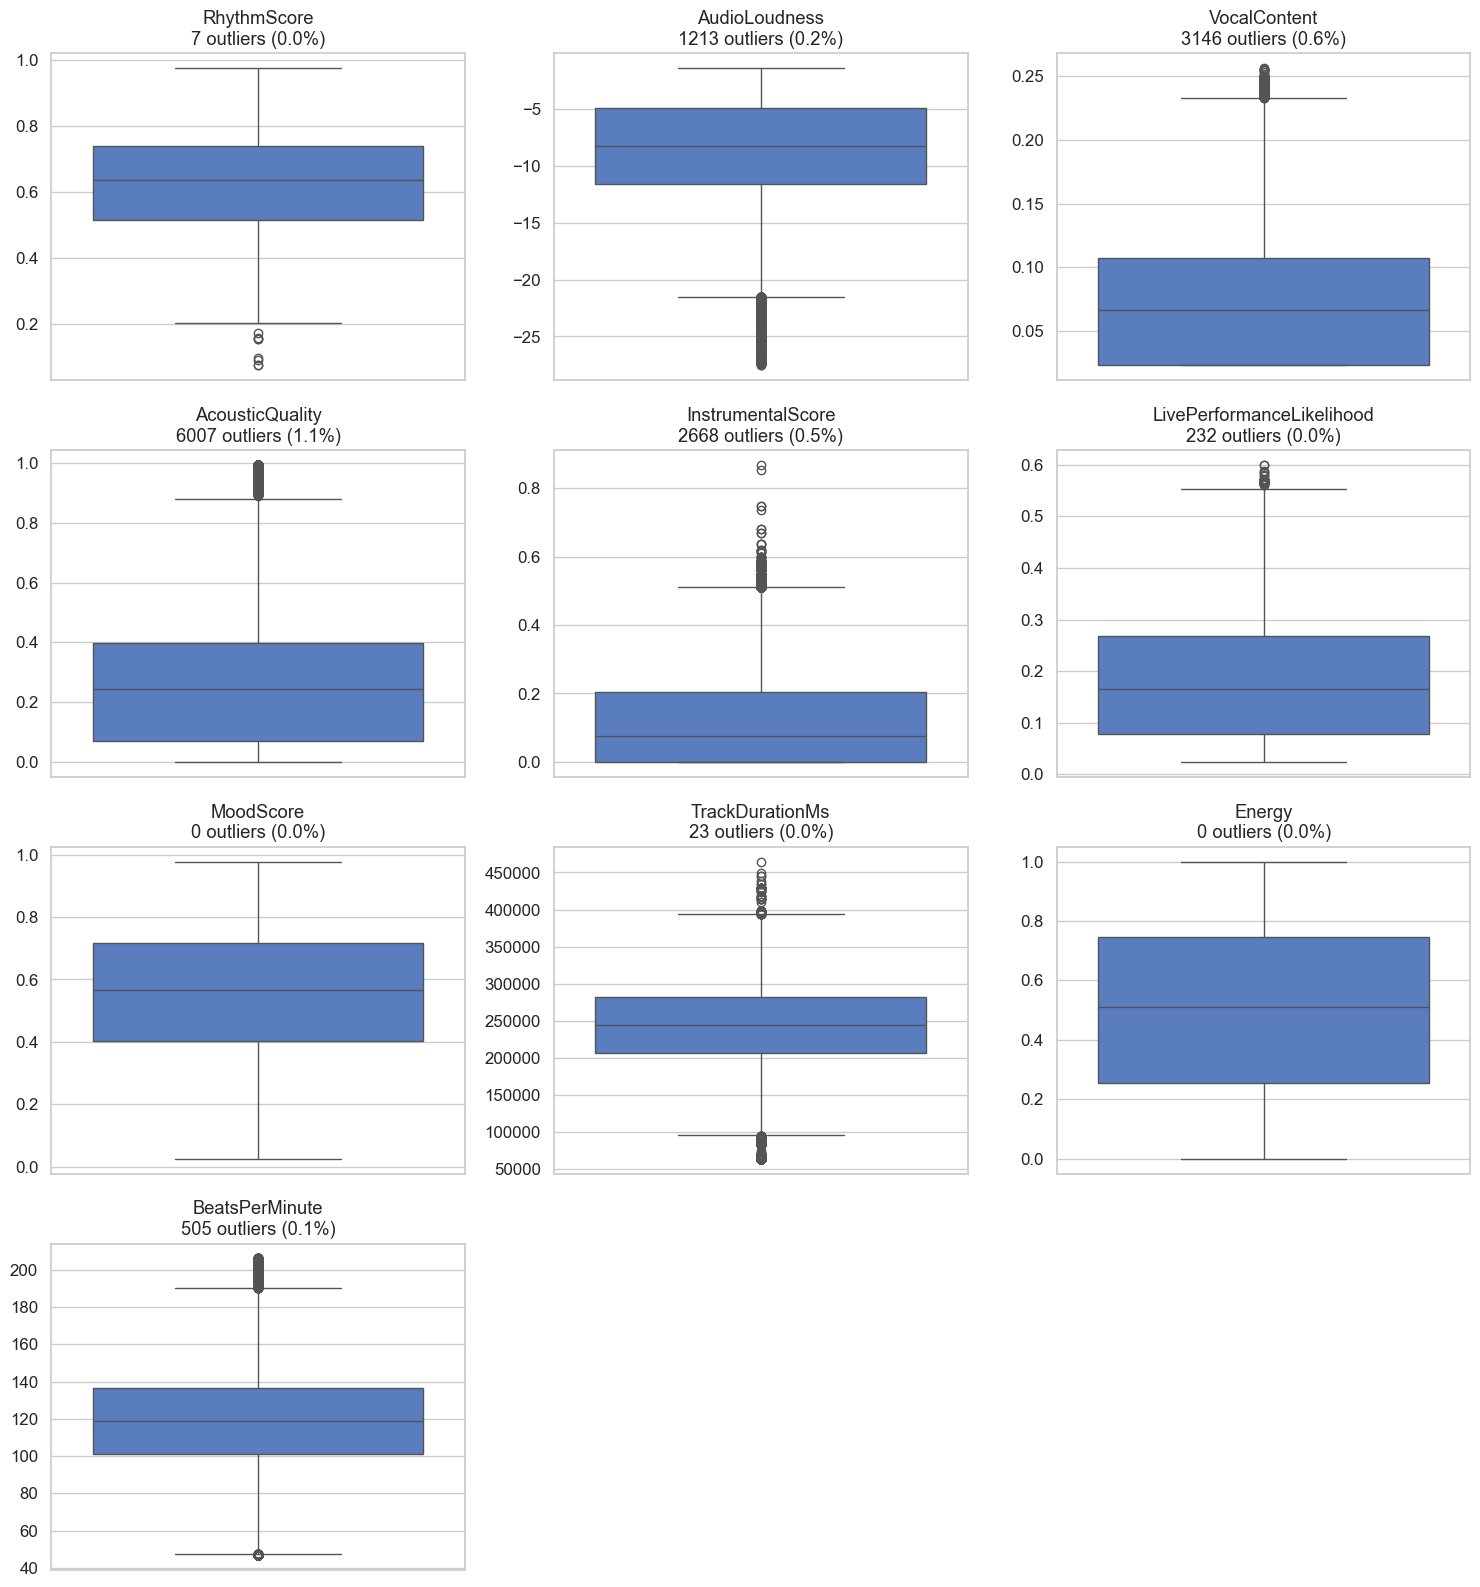


Detailed outlier statistics:

RhythmScore:
  Number of outliers: 7
  Percentage of outliers: 0.0%

AudioLoudness:
  Number of outliers: 1213
  Percentage of outliers: 0.2%

VocalContent:
  Number of outliers: 3146
  Percentage of outliers: 0.6%

AcousticQuality:
  Number of outliers: 6007
  Percentage of outliers: 1.1%

InstrumentalScore:
  Number of outliers: 2668
  Percentage of outliers: 0.5%

LivePerformanceLikelihood:
  Number of outliers: 232
  Percentage of outliers: 0.0%

MoodScore:
  Number of outliers: 0
  Percentage of outliers: 0.0%

TrackDurationMs:
  Number of outliers: 23
  Percentage of outliers: 0.0%

Energy:
  Number of outliers: 0
  Percentage of outliers: 0.0%

BeatsPerMinute:
  Number of outliers: 505
  Percentage of outliers: 0.1%


In [6]:
# Outlier analysis using box plots
cols_to_analyze = [c for c in df.columns if c != "id"]

# Create subplots for box plots
n_cols = 3
n_rows = int(np.ceil(len(cols_to_analyze) / n_cols))
plt.figure(figsize=(n_cols * 5, n_rows * 4))

# Dictionary to store outlier statistics
outlier_stats = {}

for i, col in enumerate(cols_to_analyze, 1):
    plt.subplot(n_rows, n_cols, i)
    
    # Calculate outliers using z-score method
    col_values = df[col]
    mean = col_values.mean()
    std = col_values.std()
    z_scores = (col_values - mean) / std
    outlier_mask = z_scores.abs() > 3
    
    # Store statistics
    num_outliers = outlier_mask.sum()
    percent_outliers = num_outliers / df.height
    outlier_stats[col] = {
        "num_outliers": int(num_outliers),
        "percent_outliers": float(percent_outliers)
    }
    
    # Create box plot
    sns.boxplot(y=df[col].to_numpy())
    plt.title(f"{col}\n{num_outliers} outliers ({percent_outliers:.1%})")
    plt.xticks([])  # Remove x-axis labels for cleaner look

plt.tight_layout()
plt.show()

# Print detailed statistics
print("\nDetailed outlier statistics:")
for col, stats in outlier_stats.items():
    print(f"\n{col}:")
    print(f"  Number of outliers: {stats['num_outliers']}")
    print(f"  Percentage of outliers: {stats['percent_outliers']:.1%}")

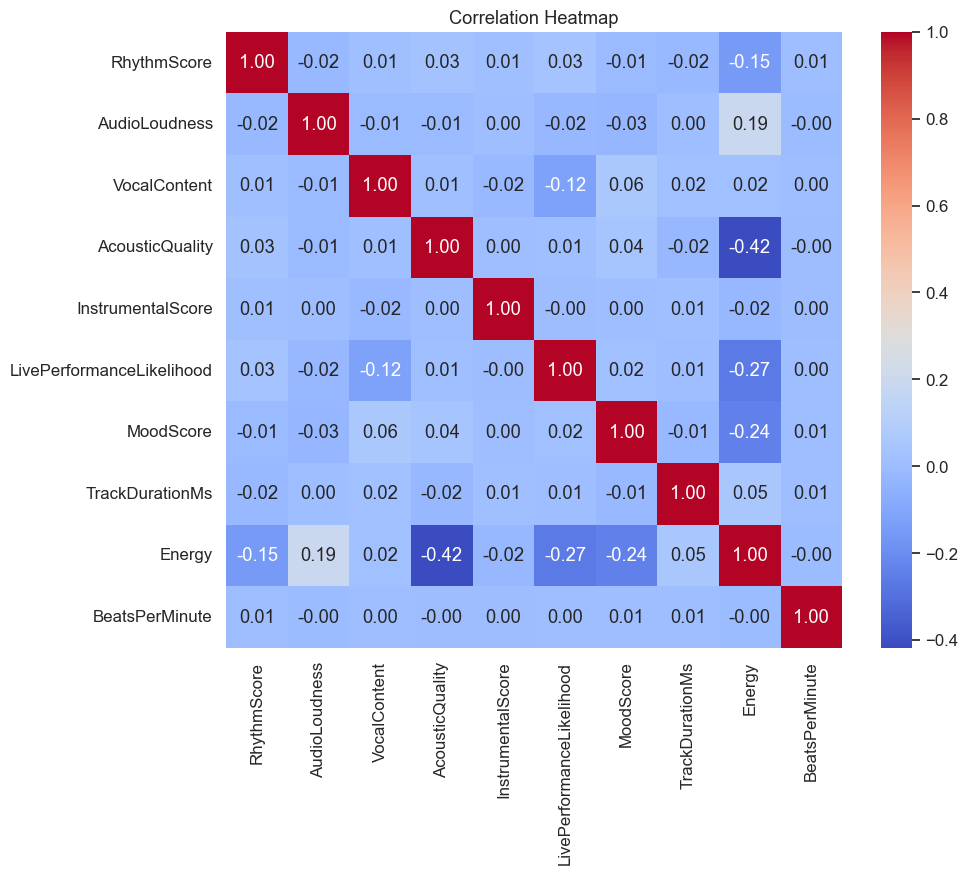

In [7]:
# Compute correlation matrix for feature columns and target
corr_matrix = df.select(feature_cols + [target_col]).to_pandas().corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap")
plt.show()

## 2. Feature Engineering

In [8]:
# Feature Engineering Ideas for this dataset

# 1. Interaction Features
df = df.with_columns(
    (pl.col("MoodScore") * pl.col("RhythmScore")).alias("MoodRhythm"),
    (pl.col("LivePerformanceLikelihood") * pl.col("AudioLoudness")).alias("PerformanceIntensity"),
    (pl.col("RhythmScore") * pl.col("Energy")).alias("RhythmEnergy"),
    (pl.col("MoodScore") * pl.col("AcousticQuality")).alias("MoodAcoustic")
)

# 2. Polynomial Features
df = df.with_columns((pl.col("Energy") ** 2).alias("Energy_squared"))


# 5. Outlier Flags
# Add binary columns indicating if a value is an outlier for each feature
for col in [c for c in df.columns if c not in ["id", target_col]]:
    mean = df[col].mean()
    std = df[col].std()
    df = df.with_columns(
        ((pl.col(col) - mean).abs() > 3 * std).alias(f"{col}_is_outlier")
    )

# 6. Ratios
df = df.with_columns((pl.col("Energy") / (pl.col("TrackDurationMs") + 1)).alias("Energy_per_Duration"))

# 8. Log Transformations
log_transform_cols = [
    "AudioLoudness",
    "VocalContent",
    "AcousticQuality",
    "InstrumentalScore",
    "LivePerformanceLikelihood"
]

for col_name in log_transform_cols:
    # If the column contains negative values, use log1p(abs(x)) * sign(x)
    if df[col_name].min() <= 0:
        df = df.with_columns(
            (pl.col(col_name).abs().log1p() * pl.col(col_name).sign()).alias(f"log_{col_name}")
        )
    else:
        df = df.with_columns(
            (pl.col(col_name).log1p()).alias(f"log_{col_name}")
        )

# 9. Temporal Features
df = df.with_columns(
    (pl.col("TrackDurationMs") / 60000).alias("TrackDurationMinutes")
)

## 3. ML Modelling

In [11]:
# Import machine learning libraries
import lightgbm as lgb
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import uniform, randint

In [12]:
# Prepare data for modeling
X = df.drop(['id', target_col])
y = df[target_col]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=None
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# Display basic statistics
print(f"\nTarget variable statistics:")
print(f"Training set - Mean: {y_train.mean():.2f}, Std: {y_train.std():.2f}")
print(f"Test set - Mean: {y_test.mean():.2f}, Std: {y_test.std():.2f}")


Training set size: 419331
Test set size: 104833

Target variable statistics:
Training set - Mean: 119.06, Std: 26.47
Test set - Mean: 118.95, Std: 26.45


In [13]:
X_train.head()

RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,MoodRhythm,PerformanceIntensity,RhythmEnergy,MoodAcoustic,Energy_squared,RhythmScore_is_outlier,AudioLoudness_is_outlier,VocalContent_is_outlier,AcousticQuality_is_outlier,InstrumentalScore_is_outlier,LivePerformanceLikelihood_is_outlier,MoodScore_is_outlier,TrackDurationMs_is_outlier,Energy_is_outlier,MoodRhythm_is_outlier,PerformanceIntensity_is_outlier,RhythmEnergy_is_outlier,MoodAcoustic_is_outlier,Energy_squared_is_outlier,Energy_per_Duration,log_AudioLoudness,log_VocalContent,log_AcousticQuality,log_InstrumentalScore,log_LivePerformanceLikelihood,TrackDurationMinutes
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,f64,f64,f64,f64,f64,f64,f64
0.781405,-4.356901,0.0235,0.000005,0.000001,0.04042,0.682512,241538.2567,0.5418,0.533319,-0.176108,0.423365,0.000004,0.293547,false,false,false,false,false,false,false,false,false,false,false,false,false,false,0.000002,-1.678386,0.023228,0.000005,0.000001,0.039625,4.025638
0.532378,-8.9083,0.0235,0.012917,0.03224,0.07614,0.483868,180583.7425,0.994667,0.2576,-0.678275,0.529539,0.00625,0.989362,false,false,false,false,false,false,false,false,false,false,false,false,false,false,0.000006,-2.293373,0.023228,0.012834,0.031731,0.07338,3.009729
0.912855,-14.35571,0.120433,0.372479,0.127346,0.0243,0.440126,291223.4702,0.566267,0.401771,-0.348844,0.51692,0.163938,0.320658,false,false,false,false,false,false,false,false,false,false,false,false,false,false,0.000002,-2.731487,0.113715,0.316619,0.119866,0.024009,4.853725
0.471765,-5.637425,0.043413,0.504548,0.162065,0.065687,0.485008,313870.0566,0.492067,0.22881,-0.370306,0.23214,0.24471,0.24213,false,false,false,false,false,false,false,false,false,false,false,false,false,false,0.000002,-1.892724,0.042497,0.408493,0.150199,0.06362,5.231168
0.975,-11.681864,0.031886,0.086502,0.000001,0.308907,0.682415,243435.6405,0.453667,0.665354,-3.608609,0.442325,0.05903,0.205813,false,false,false,false,false,false,false,false,false,false,false,false,false,false,0.000002,-2.540173,0.031388,0.082963,0.000001,0.269192,4.057261


In [14]:
# Define parameter distributions for RandomizedSearchCV
param_distributions = {
    'n_estimators': randint(100, 1000),
    'learning_rate': uniform(0.01, 0.3),
    'num_leaves': randint(20, 300),
    'max_depth': randint(3, 15),
    'min_child_samples': randint(5, 100),
    'min_child_weight': uniform(0.001, 0.01),
    'subsample': uniform(0.6, 0.4),  # 0.6 to 1.0
    'colsample_bytree': uniform(0.6, 0.4),  # 0.6 to 1.0
    'reg_alpha': uniform(0, 1),
    'reg_lambda': uniform(0, 1),
}

# Create LightGBM regressor
lgb_regressor = lgb.LGBMRegressor(
    objective='regression',
    metric='rmse',
    verbosity=-1,
    random_state=42
)

In [15]:
# Perform Randomized Search with Cross-Validation
print("Starting RandomizedSearchCV...")

random_search = RandomizedSearchCV(
    estimator=lgb_regressor,
    param_distributions=param_distributions,
    n_iter=100,  # Number of parameter combinations to try
    cv=5,  # 5-fold cross-validation
    scoring='neg_mean_squared_error',
    n_jobs=-1,  # Use all available cores
    random_state=42,
    verbose=1
)

# Fit the random search
random_search.fit(X_train, y_train)

print(f"Best score (negative MSE): {random_search.best_score_:.4f}")
print(f"Best RMSE: {np.sqrt(-random_search.best_score_):.4f}")

print("\nBest parameters found:")
for param, value in random_search.best_params_.items():
    print(f"- {param}: {value}")

Starting RandomizedSearchCV...
Fitting 5 folds for each of 100 candidates, totalling 500 fits


c:\Users\zane6\anaconda3\Lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best score (negative MSE): -700.5277
Best RMSE: 26.4675

Best parameters found:
- colsample_bytree: 0.7043574493366855
- learning_rate: 0.014591362087115426
- max_depth: 5
- min_child_samples: 62
- min_child_weight: 0.006010398839152592
- n_estimators: 424
- num_leaves: 23
- reg_alpha: 0.6158511643899138
- reg_lambda: 0.9438916045607572
- subsample: 0.977700638850067


FINAL MODEL PERFORMANCE
Root Mean Square Error (RMSE): 26.4401
Mean Absolute Error (MAE): 21.1820
R² Score: 0.0004
Mean Squared Error (MSE): 699.0782

Feature Importance:
shape: (35, 2)
┌──────────────────────────────┬────────────┐
│ feature                      ┆ importance │
│ ---                          ┆ ---        │
│ str                          ┆ i32        │
╞══════════════════════════════╪════════════╡
│ RhythmScore_is_outlier       ┆ 0          │
│ InstrumentalScore_is_outlier ┆ 0          │
│ MoodScore_is_outlier         ┆ 0          │
│ TrackDurationMs_is_outlier   ┆ 0          │
│ Energy_is_outlier            ┆ 0          │
│ …                            ┆ …          │
│ Energy_per_Duration          ┆ 594        │
│ Energy                       ┆ 602        │
│ MoodAcoustic                 ┆ 644        │
│ MoodScore                    ┆ 733        │
│ TrackDurationMs              ┆ 831        │
└──────────────────────────────┴────────────┘


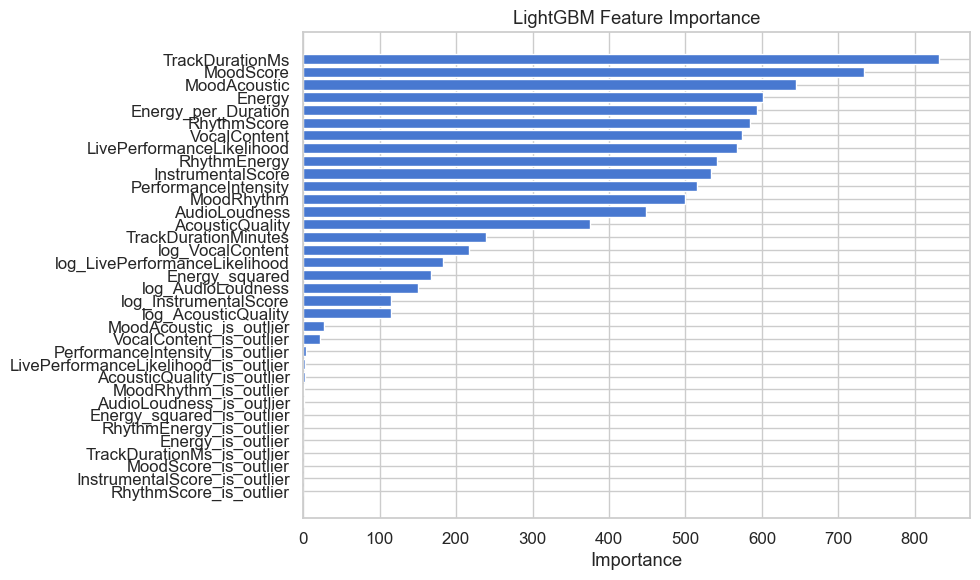

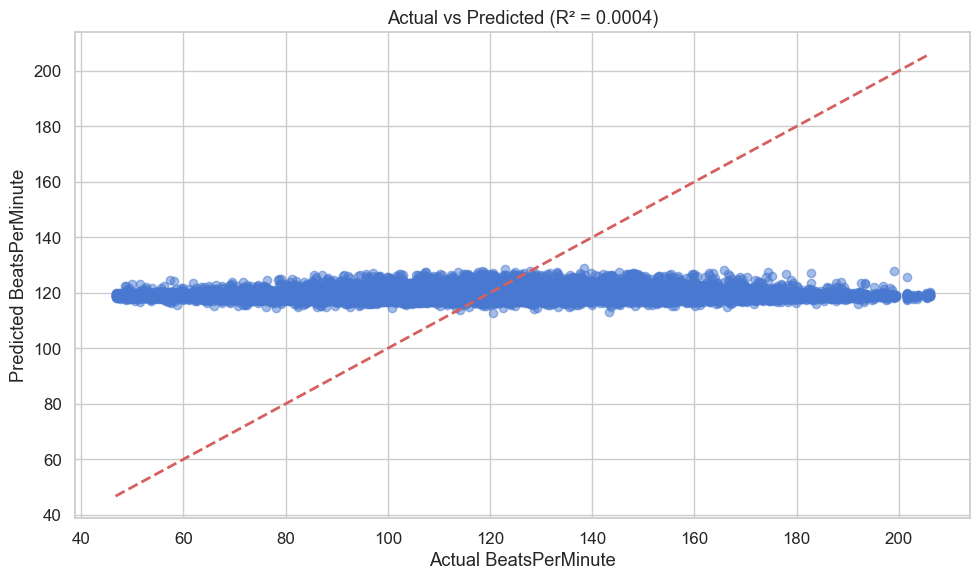

In [16]:
# Train final model with best parameters and evaluate
best_lgb = random_search.best_estimator_

# Make predictions on test set
y_pred = best_lgb.predict(X_test)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("="*50)
print("FINAL MODEL PERFORMANCE")
print("="*50)
print(f"Root Mean Square Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")

# Feature importance
# Get feature names from the training data (excluding id and target)
final_features = [col for col in X_train.columns if col not in ['id', 'BeatsPerMinute']]

feature_importance = pl.DataFrame({
    'feature': final_features,
    'importance': best_lgb.feature_importances_
}).sort('importance')

print("\nFeature Importance:")
print(feature_importance)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.title('LightGBM Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# Plot predictions vs actual
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual BeatsPerMinute')
plt.ylabel('Predicted BeatsPerMinute')
plt.title(f'Actual vs Predicted (R² = {r2:.4f})')
plt.tight_layout()
plt.show()

In [22]:
test_df = pl.read_csv("test.csv")

# 1. Interaction Features
test_df = test_df.with_columns(
    (pl.col("MoodScore") * pl.col("RhythmScore")).alias("MoodRhythm"),
    (pl.col("LivePerformanceLikelihood") * pl.col("AudioLoudness")).alias("PerformanceIntensity"),
    (pl.col("RhythmScore") * pl.col("Energy")).alias("RhythmEnergy"),
    (pl.col("MoodScore") * pl.col("AcousticQuality")).alias("MoodAcoustic")
)

# 2. Polynomial Features
test_df = test_df.with_columns((pl.col("Energy") ** 2).alias("Energy_squared"))


# 5. Outlier Flags
# Add binary columns indicating if a value is an outlier for each feature
for col in [c for c in test_df.columns if c not in ["id", target_col]]:
    mean = test_df[col].mean()
    std = test_df[col].std()
    test_df = test_df.with_columns(
        ((pl.col(col) - mean).abs() > 3 * std).alias(f"{col}_is_outlier")
    )

# 6. Ratios
test_df = test_df.with_columns((pl.col("Energy") / (pl.col("TrackDurationMs") + 1)).alias("Energy_per_Duration"))

# 8. Log Transformations
log_transform_cols = [
    "AudioLoudness",
    "VocalContent",
    "AcousticQuality",
    "InstrumentalScore",
    "LivePerformanceLikelihood"
]

for col_name in log_transform_cols:
    # If the column contains negative values, use log1p(abs(x)) * sign(x)
    if test_df[col_name].min() <= 0:
        test_df = test_df.with_columns(
            (pl.col(col_name).abs().log1p() * pl.col(col_name).sign()).alias(f"log_{col_name}")
        )
    else:
        test_df = test_df.with_columns(
            (pl.col(col_name).log1p()).alias(f"log_{col_name}")
        )

# 9. Temporal Features
test_df = test_df.with_columns(
    (pl.col("TrackDurationMs") / 60000).alias("TrackDurationMinutes")
)

print(f"Test dataset shape: {test_df.shape}")

Test dataset shape: (174722, 36)


In [28]:
# Load test data and make predictions for submission
X_test_submission = test_df.drop(['id'])

# Make predictions
test_predictions = best_lgb.predict(X_test_submission)

# Create submission dataframe
submission = pl.DataFrame({
    'id': test_df['id'],
    'BeatsPerMinute': test_predictions
})

print(f"Submission shape: {submission.shape}")
print(f"Prediction statistics:")
print(f"- Mean: {test_predictions.mean():.2f}")
print(f"- Std: {test_predictions.std():.2f}")
print(f"- Min: {test_predictions.min():.2f}")
print(f"- Max: {test_predictions.max():.2f}")

# Save submission file
submission.write_csv('submission.csv')
print("\nSubmission file saved as 'submission.csv'")

# Display first few predictions
print("\nFirst 10 predictions:")
print(submission.head(10))

Submission shape: (174722, 2)
Prediction statistics:
- Mean: 119.06
- Std: 0.81
- Min: 112.46
- Max: 129.38

Submission file saved as 'submission.csv'

First 10 predictions:
shape: (10, 2)
┌────────┬────────────────┐
│ id     ┆ BeatsPerMinute │
│ ---    ┆ ---            │
│ i64    ┆ f64            │
╞════════╪════════════════╡
│ 524164 ┆ 118.865737     │
│ 524165 ┆ 119.252696     │
│ 524166 ┆ 119.230434     │
│ 524167 ┆ 119.332049     │
│ 524168 ┆ 119.740863     │
│ 524169 ┆ 118.800907     │
│ 524170 ┆ 118.428542     │
│ 524171 ┆ 118.767775     │
│ 524172 ┆ 119.221776     │
│ 524173 ┆ 118.646607     │
└────────┴────────────────┘
